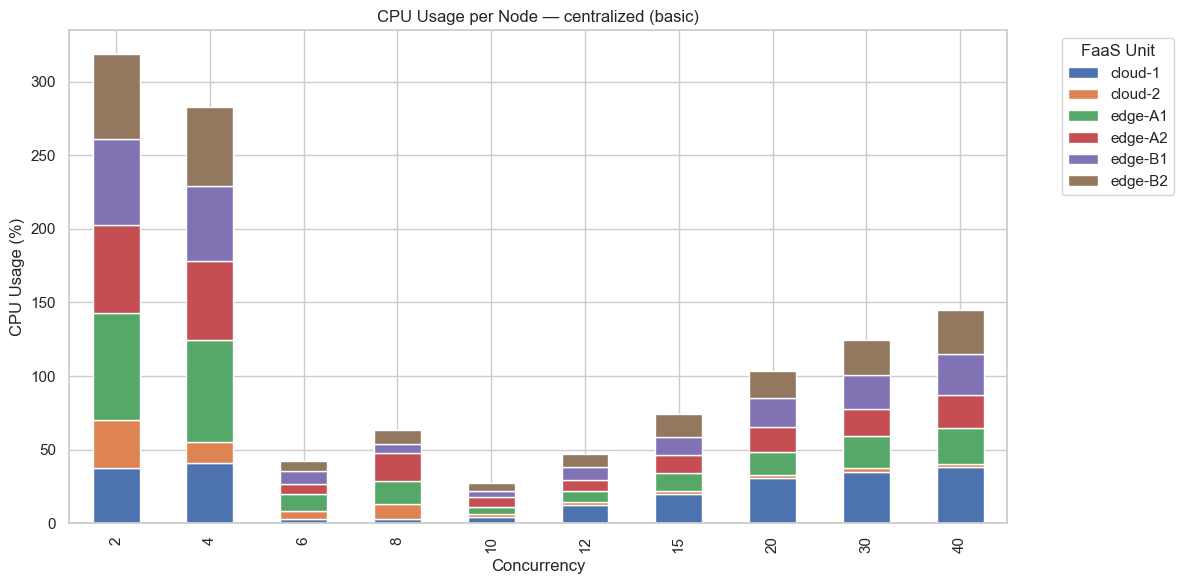

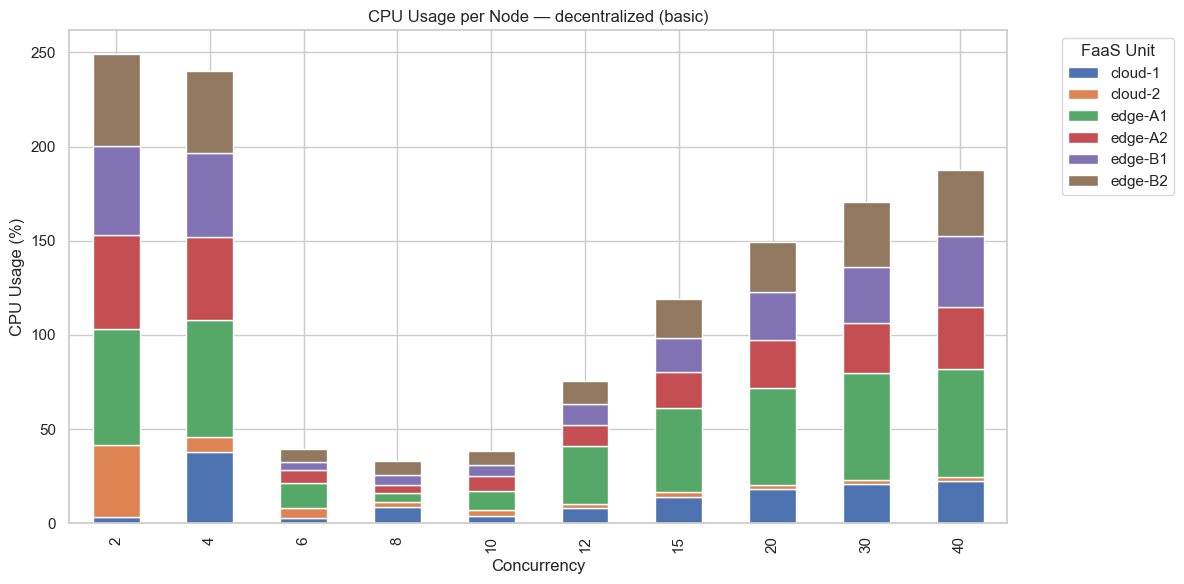

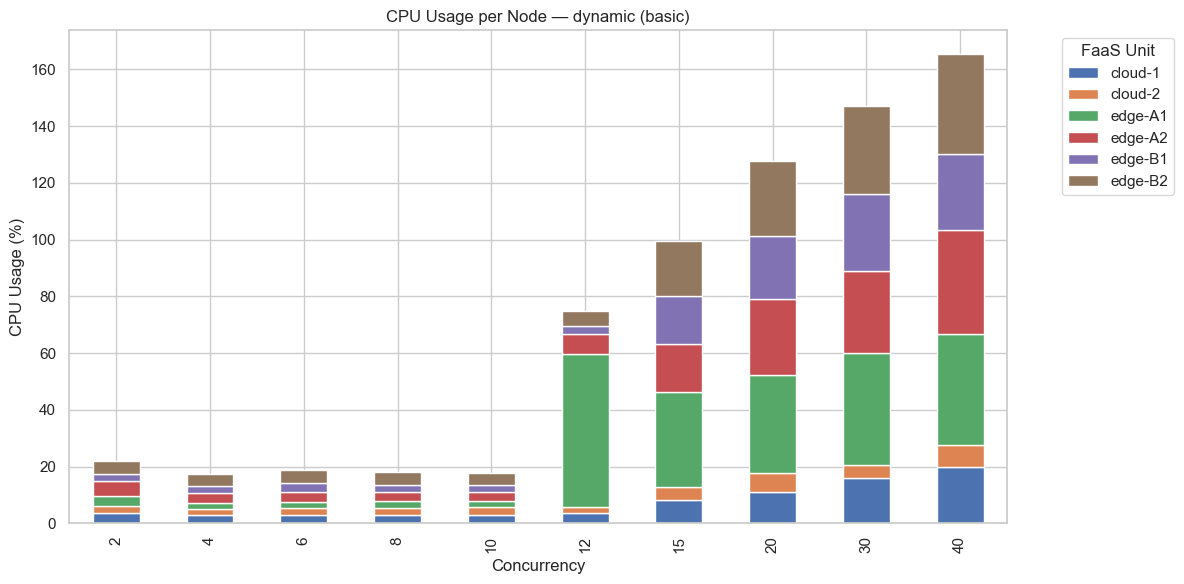

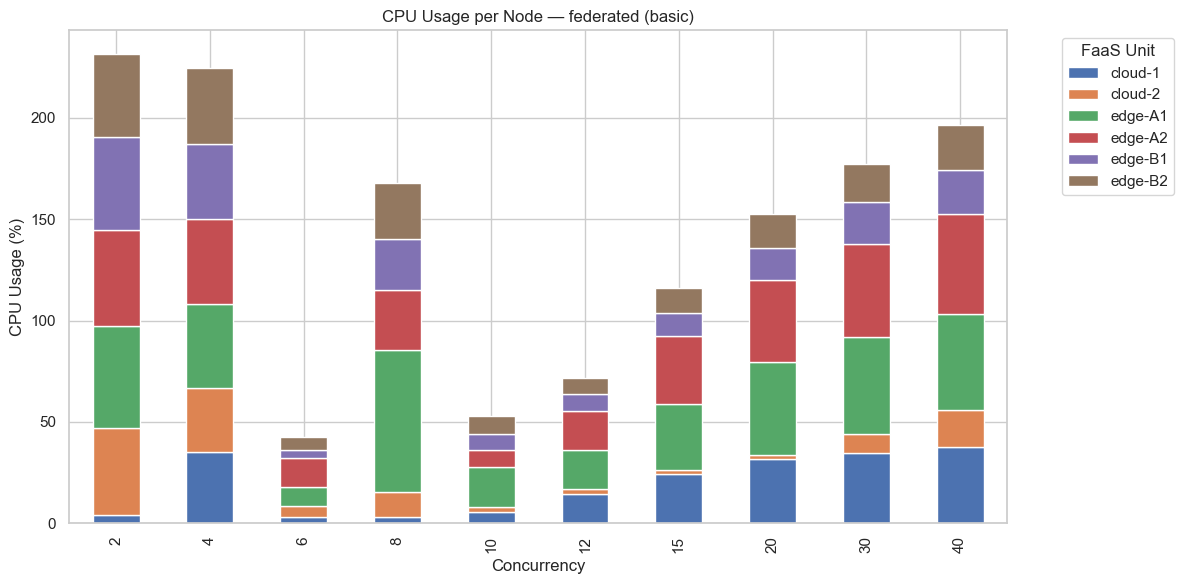

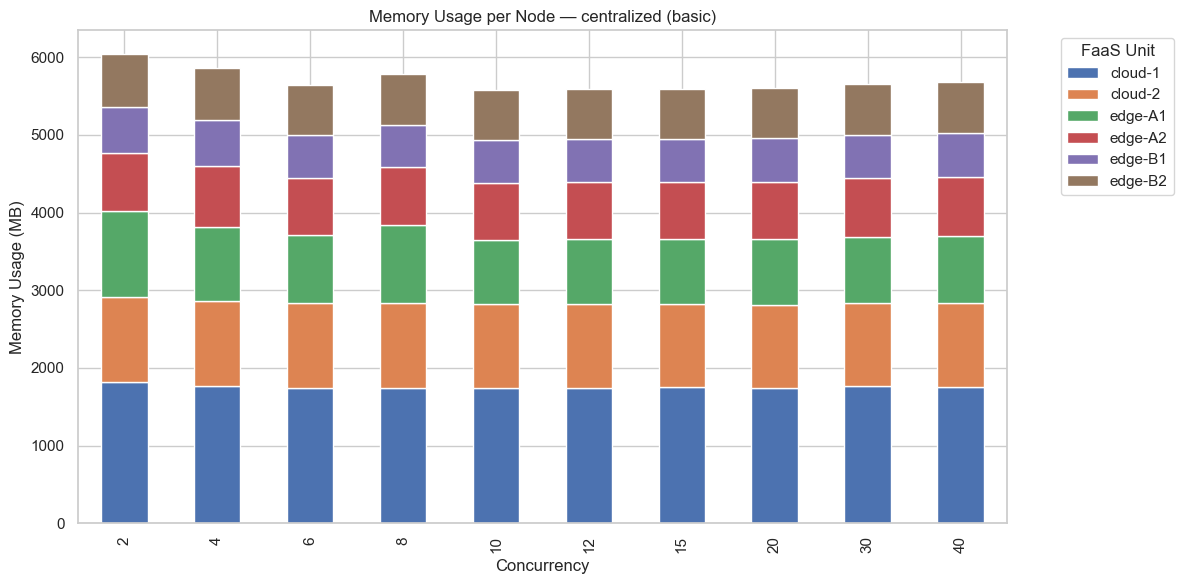

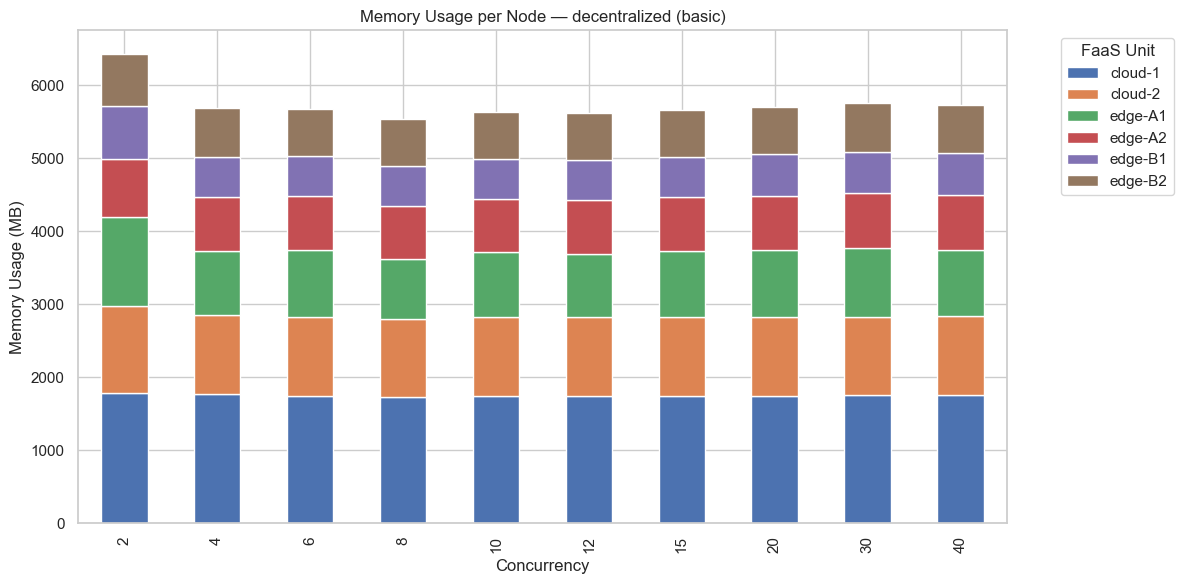

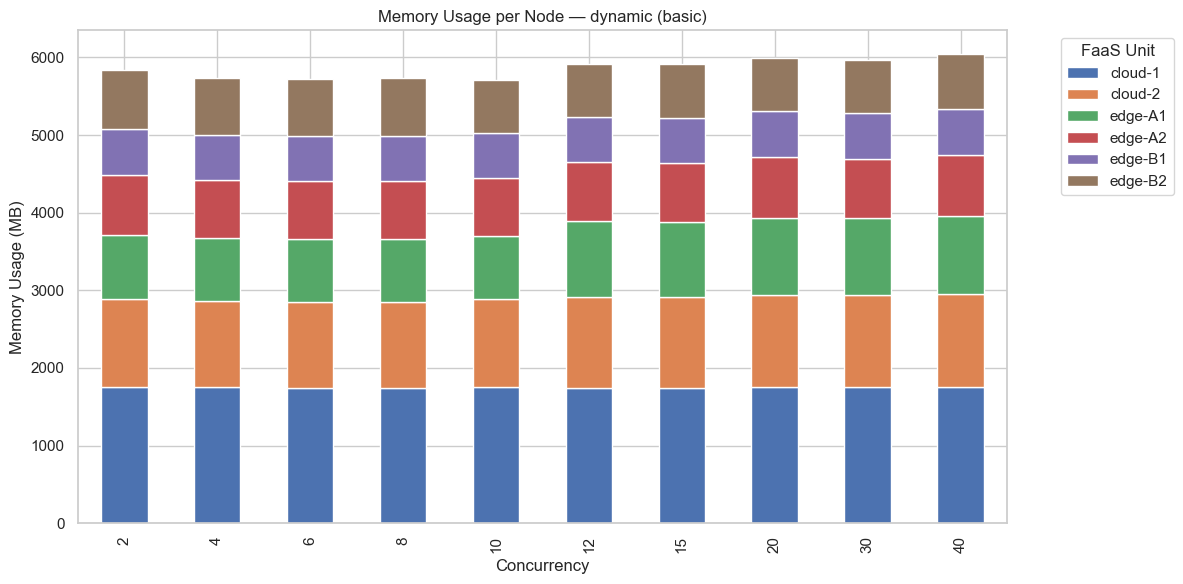

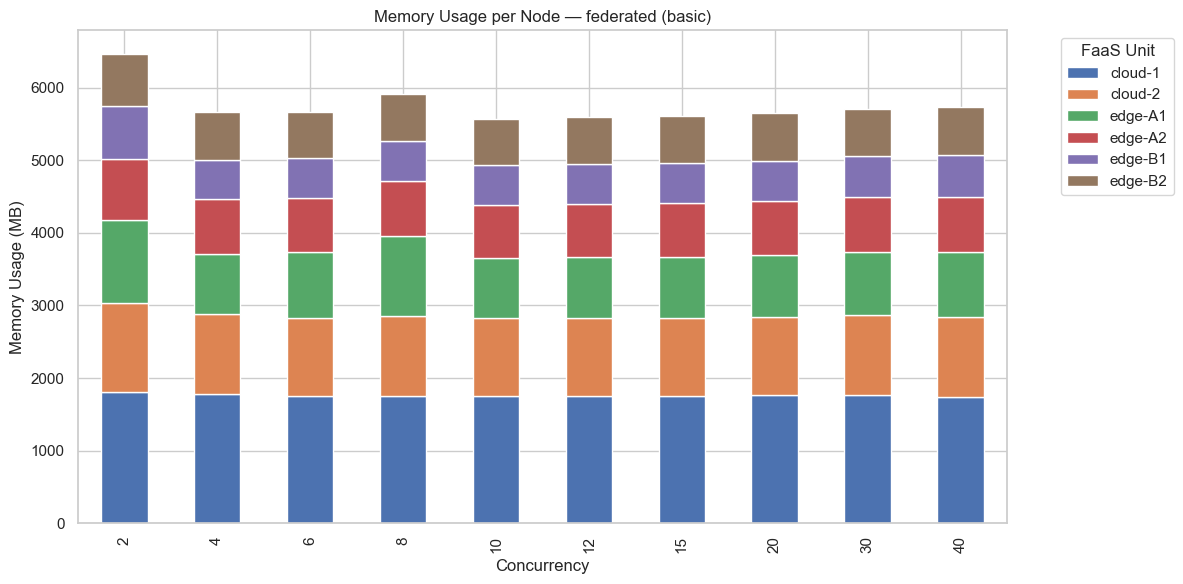

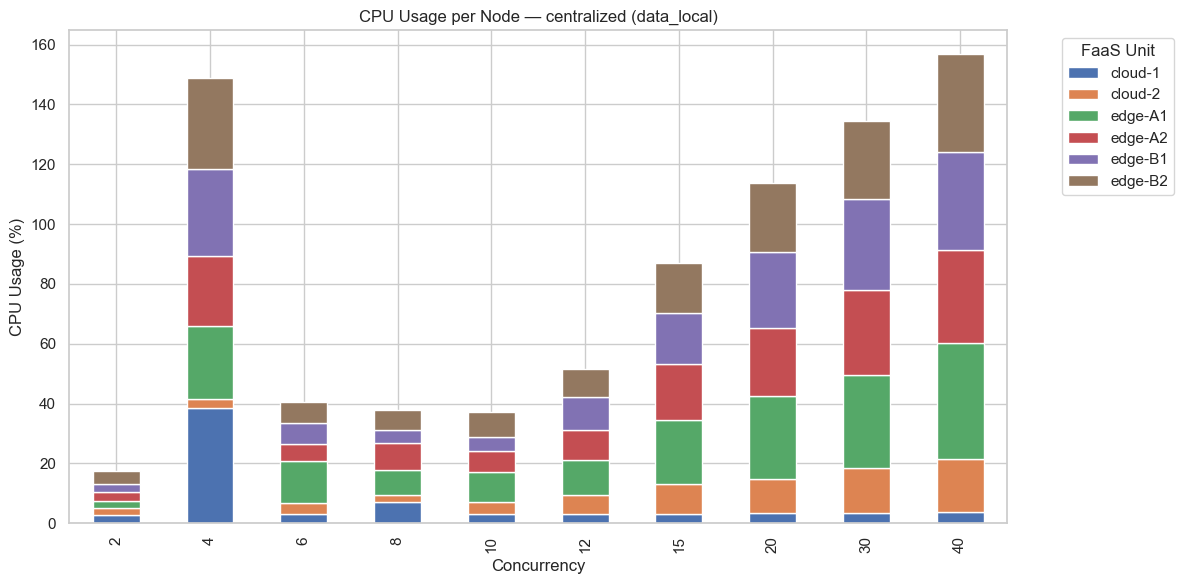

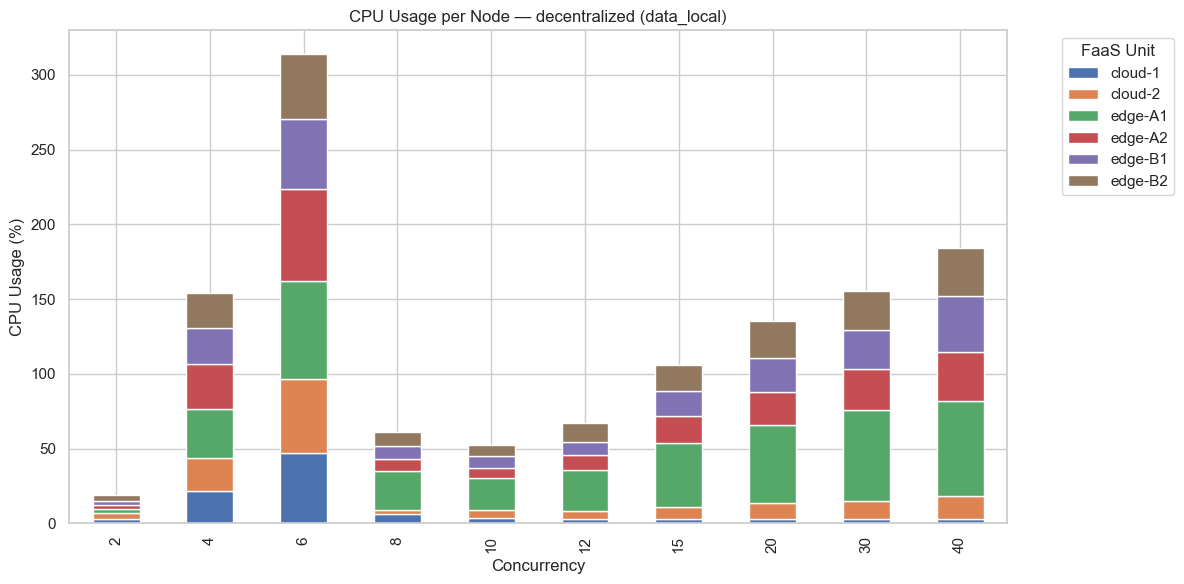

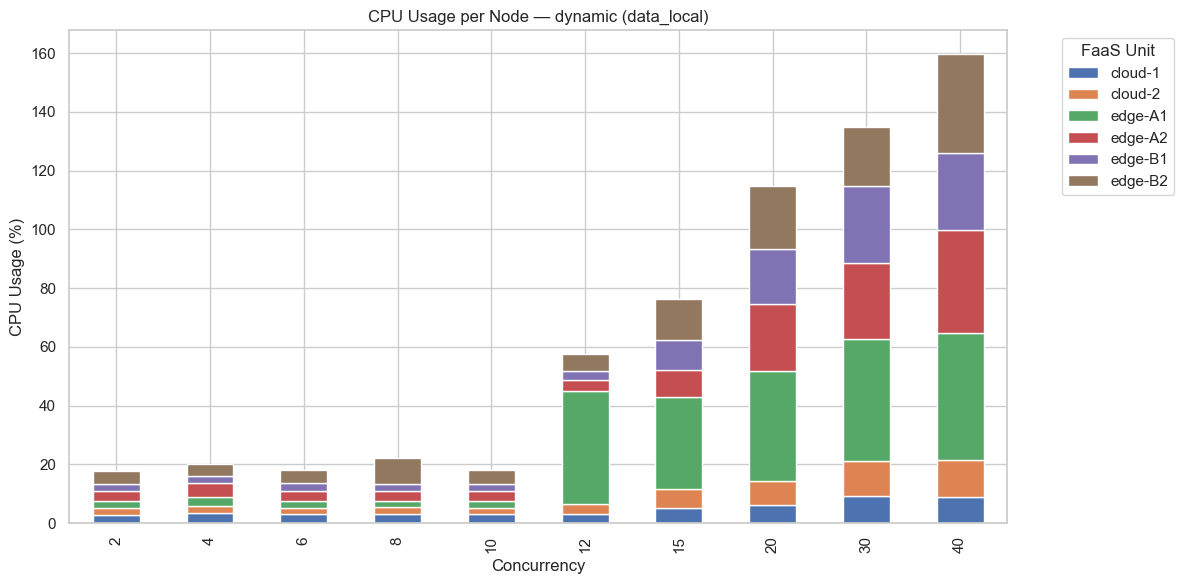

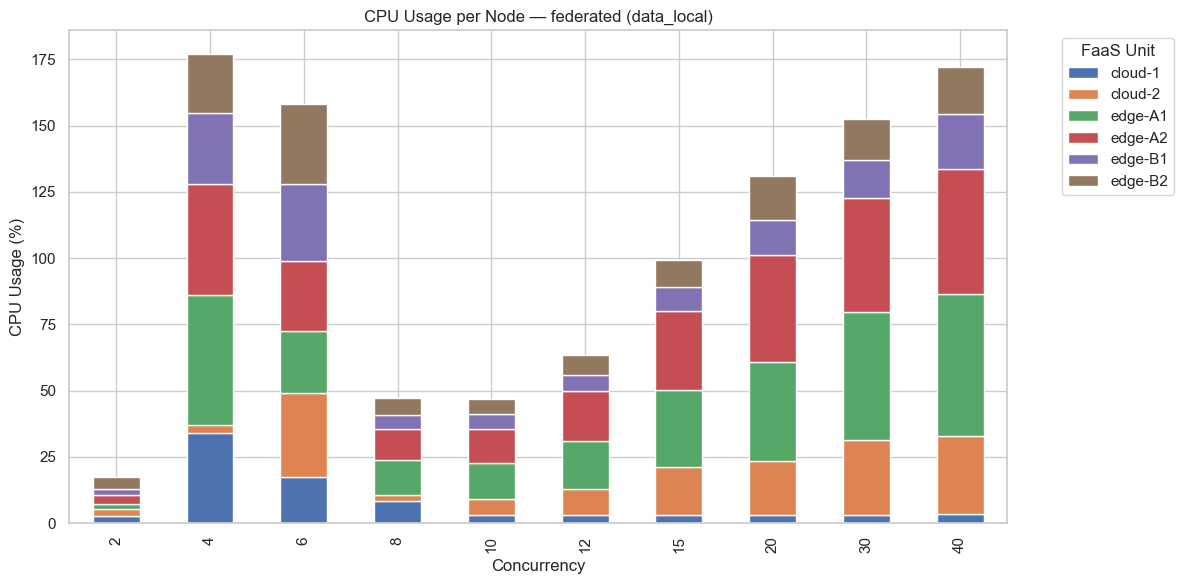

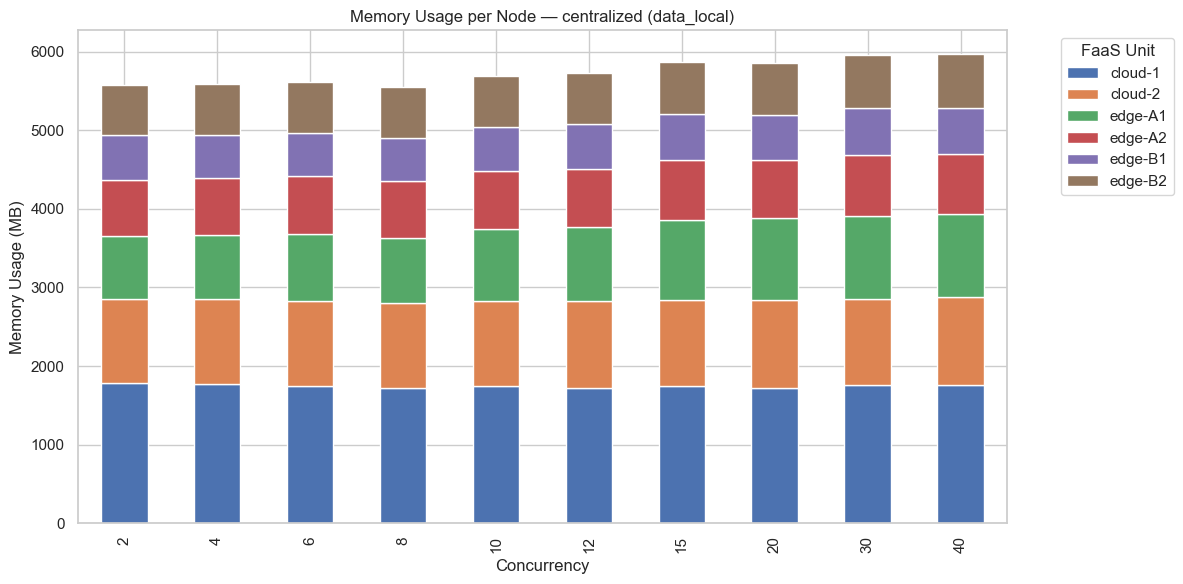

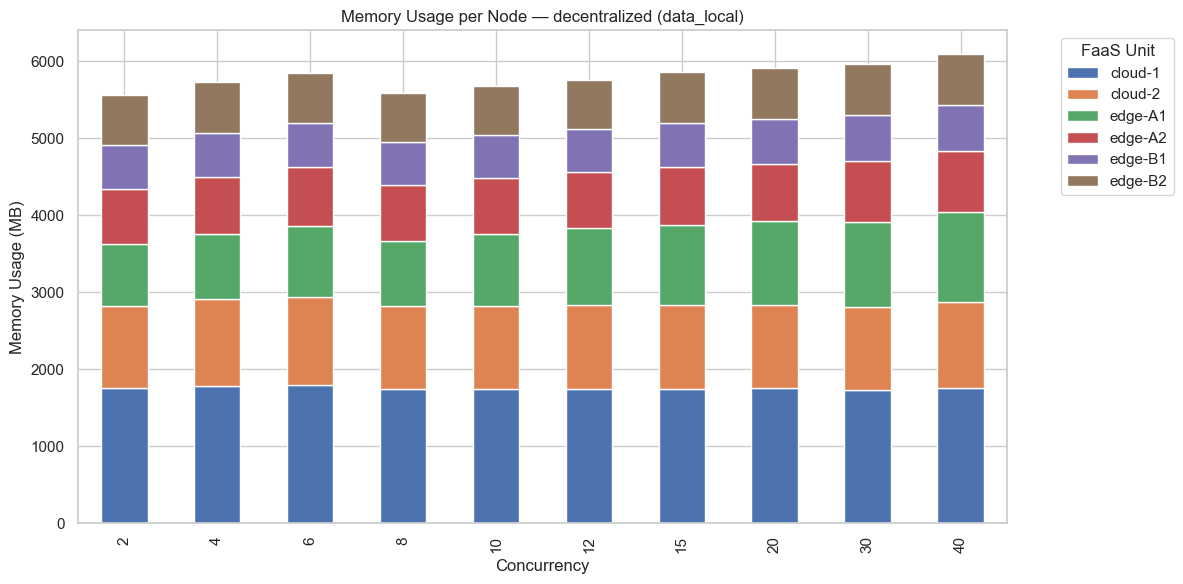

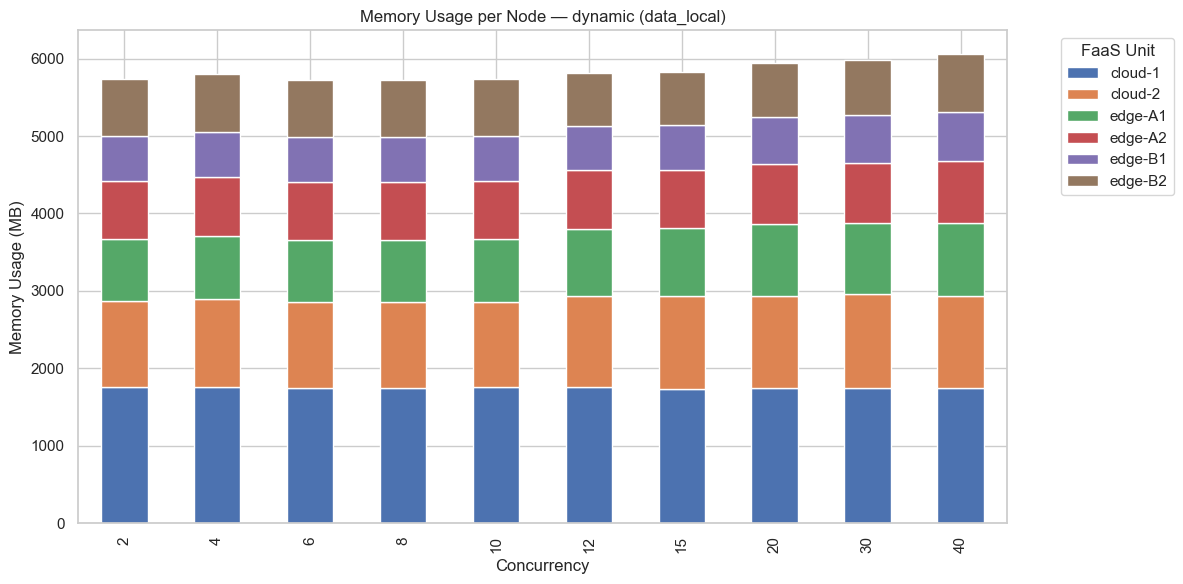

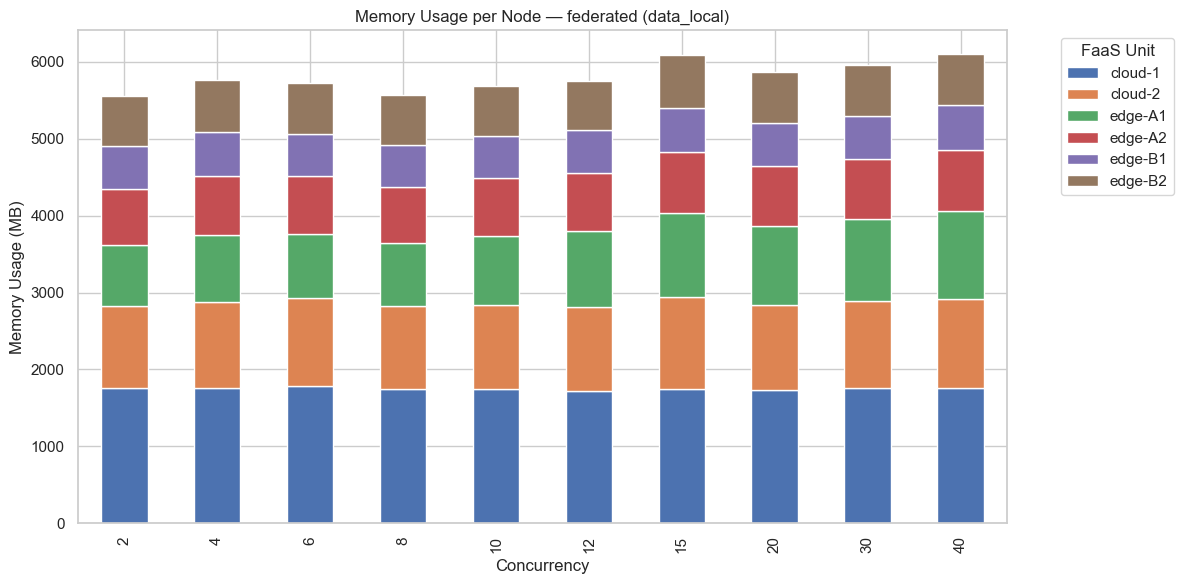

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


def load_metrics_data(base_folder):
    archs = ["centralized", "federated", "decentralized", "dynamic"]
    df_list = []
    for arch in archs:
        path = os.path.join(base_folder, f"metrics_unit_{arch}_all.csv")
        if os.path.exists(path):
            df = pd.read_csv(path)
            df["architecture"] = arch
            df_list.append(df)
    return pd.concat(df_list, ignore_index=True)


def plot_stacked_usage(df, fn_type, resource_col, ylabel, title_prefix):
    grouped = df.groupby(["concurrency", "architecture", "faas_unit"])[resource_col].mean().reset_index()
    architectures = grouped["architecture"].unique()

    for arch in architectures:
        data = grouped[grouped["architecture"] == arch]
        pivot = data.pivot(index="concurrency", columns="faas_unit", values=resource_col).fillna(0)
        pivot.sort_index(inplace=True)
        pivot.plot(kind="bar", stacked=True)
        plt.title(f"{title_prefix} Usage per Node — {arch} ({fn_type})")
        plt.ylabel(ylabel)
        plt.xlabel("Concurrency")
        plt.legend(title="FaaS Unit", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()


# Load and plot for both function types
for fn_type in ["basic", "data_local"]:
    df = load_metrics_data(fn_type)
    plot_stacked_usage(df, fn_type, "avg_cpu", "CPU Usage (%)", "CPU")
    plot_stacked_usage(df, fn_type, "avg_mem_MB", "Memory Usage (MB)", "Memory")

In [1]:
import os
import re
import pandas as pd
from glob import glob

def merge_single_architecture(folder_path, target_arch):
    # 支持大小写
    pattern = re.compile(rf"metrics_unit_{target_arch.lower()}_(\d+)\.csv")
    
    all_files = glob(os.path.join(folder_path, f"metrics_unit_{target_arch.lower()}_*.csv"))
    
    dfs = []
    for file in all_files:
        filename = os.path.basename(file)
        match = pattern.match(filename)
        if match:
            concurrency = int(match.group(1))
            df = pd.read_csv(file)
            df["concurrency"] = concurrency
            df["architecture"] = target_arch
            dfs.append(df)

    if dfs:
        merged_df = pd.concat(dfs, ignore_index=True)
        out_path = os.path.join(folder_path, f"metrics_unit_{target_arch.lower()}_all.csv")
        merged_df.to_csv(out_path, index=False)
        print(f"✅ Saved merged file for '{target_arch}' to: {out_path}")
    else:
        print(f"⚠️ No files found for architecture '{target_arch}' in {folder_path}")

# ✏️ 修改这两个变量来切换架构与路径
target_architecture = "dynamic"  # 例如：dynamic、federated、centralized、decentralized
merge_single_architecture("basic", target_architecture)
merge_single_architecture("data_local", target_architecture)


✅ Saved merged file for 'dynamic' to: basic\metrics_unit_dynamic_all.csv
✅ Saved merged file for 'dynamic' to: data_local\metrics_unit_dynamic_all.csv
